# Capítulos 13 y 14: Transformada de Fourier, DFT y FFT

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/07-transformada-DFT.ipynb)

Notebook que acompaña a los Capítulos 13 (Transformada de Fourier) y 14 (La transformada de Fourier discreta) de *Introducción al Modelado Continuo*. Reproduce las figuras de los dos capítulos (las tres transformadas de los ejemplos, el aliasing) y agrega otras (la grilla de frecuencias de la DFT, el esquema de la FFT, su costo y el muestreo de la temperatura), verificando numéricamente lo que el texto afirma: las transformadas de la indicadora, la exponencial y la gaussiana, la dualidad ancho/ancho de banda, el teorema de la convolución y la identidad de Plancherel; en el caso discreto, la representación matricial $\hat{\mathbf f} = A(\omega)\mathbf f$ y su inversa, Plancherel, la convolución circular, la interpolación trigonométrica, el aliasing y el algoritmo de Cooley–Tukey.

**Convención.** Usamos la del texto en todo el notebook: $\hat f(\xi) = \int_{\mathbb R} f(x)\,e^{-2\pi i\xi x}\,dx$ (frecuencia $\xi$ en ciclos por unidad de $x$, sin factores $2\pi$ en la inversa), y en el caso discreto $\hat f[k] = \sum_{j=0}^{N-1} f[j]\,e^{-2\pi i jk/N}$, que es exactamente lo que calcula `np.fft.fft` (sin normalizar). Volvemos al problema conductor, la **temperatura horaria**, en la sección de muestreo y aliasing.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imc import estilo, espectro, datos
from imc.estilo import COLORES, CICLO

estilo.activar(fuente=14)   # las figuras van a 0.6-0.7\textwidth (~9-11 cm): fuente grande para que se lean impresas
plt.close(plt.figure())   # inicializa el backend inline fuera de los rc_context de abajo (si no, las figuras no se muestran)
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.8-0.95\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def transformada(f, xi, R=10.0, n=20001):
    '''Transformada de Fourier hat f(xi) = int f(x) e^(-2 pi i xi x) dx (convención del texto), aproximando la
    integral por la regla del trapecio en [-R, R] con n puntos (f tiene que ser despreciable fuera de [-R, R]).'''
    x = np.linspace(-R, R, n)
    fx = f(x)
    return np.array([np.trapezoid(fx * np.exp(-2j * np.pi * s * x), x) for s in np.atleast_1d(xi)])


def matriz_fourier(N):
    '''Matriz A(omega) de la Sección 14.3: A[k, j] = omega^(jk) con omega = e^(-2 pi i / N).'''
    j = np.arange(N)
    return np.exp(-2j * np.pi / N) ** np.outer(j, j)

## 13.2 Definición y ejemplos: las tres transformadas

Los tres ejemplos del texto, con la definición $\hat f(\xi) = \int f(x)e^{-2\pi i\xi x}\,dx$:

| $f(x)$ | $\hat f(\xi)$ |
|---|---|
| $\mathbf 1_{[-1,1]}(x)$ | $\dfrac{\sin(2\pi\xi)}{\pi\xi}$ |
| $e^{-2\pi\lvert x\rvert}$ | $\dfrac{1}{\pi(1+\xi^2)}$ |
| $e^{-x^2}$ | $\sqrt\pi\,e^{-\pi^2\xi^2}$ |

Comparamos cada fórmula con la integral calculada numéricamente (regla del trapecio: para la indicadora integramos exactamente en $[-1,1]$; para las otras dos en $[-10,10]$, donde el resto es menor que $10^{-27}$). **Figura `transformadas`** (reemplaza a `transformada1/2/3`, que eran tres archivos separados): un panel $3\times2$ con la función a la izquierda y su transformada a la derecha, en los mismos rangos de $x$ y $\xi$ para las tres filas, de modo que se vea la dualidad: cuanto más concentrada es $f$, más ancha es $\hat f$ (la gaussiana $e^{-x^2}$, de ancho $\sim 1$, tiene una transformada de ancho $\sim 1/\pi$; la indicadora, con bordes abruptos, tiene una transformada que decae lento, como $1/\xi$).

$f(x) = \mathbf{1}_{[-1,1]}(x)$  max |hat f numérica - fórmula| en [-5, 5]: 1.2e-08


$f(x) = e^{-2\pi|x|}$            max |hat f numérica - fórmula| en [-5, 5]: 2.6e-07


$f(x) = e^{-x^2}$                max |hat f numérica - fórmula| en [-5, 5]: 4.4e-16


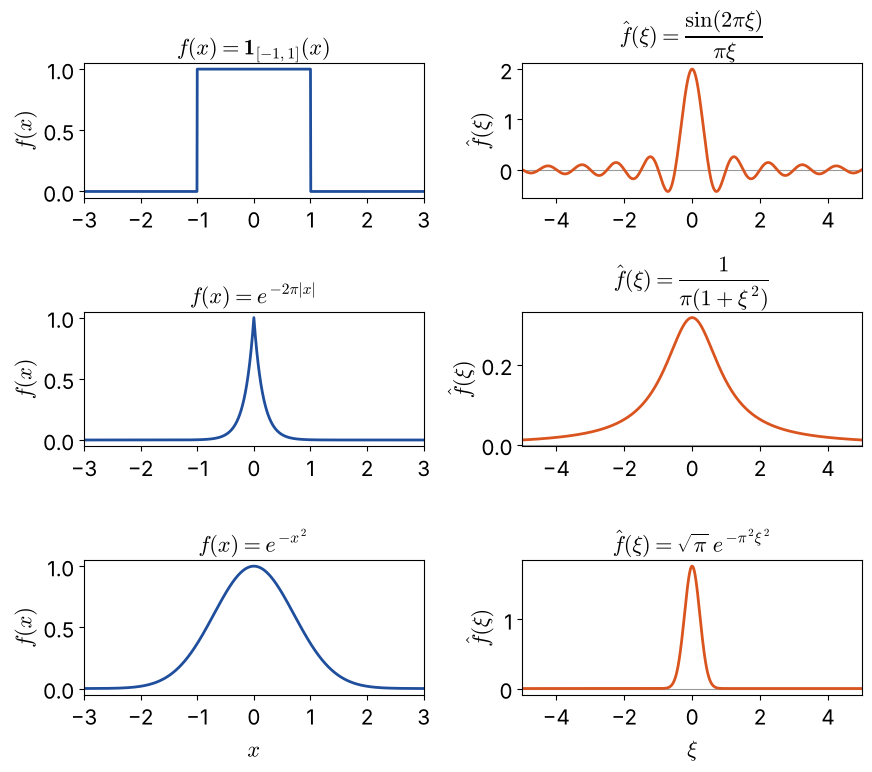

In [2]:
ejemplos = [(r"$f(x) = \mathbf{1}_{[-1,1]}(x)$", lambda x: np.where(np.abs(x) <= 1, 1.0, 0.0),
             r"$\hat f(\xi) = \dfrac{\sin(2\pi\xi)}{\pi\xi}$", lambda s: np.sinc(2 * s) * 2, 1.0),
            (r"$f(x) = e^{-2\pi|x|}$", lambda x: np.exp(-2 * np.pi * np.abs(x)),
             r"$\hat f(\xi) = \dfrac{1}{\pi(1+\xi^2)}$", lambda s: 1 / (np.pi * (1 + s**2)), 10.0),
            (r"$f(x) = e^{-x^2}$", lambda x: np.exp(-x**2),
             r"$\hat f(\xi) = \sqrt{\pi}\,e^{-\pi^2\xi^2}$", lambda s: np.sqrt(np.pi) * np.exp(-np.pi**2 * s**2), 10.0)]
xx = np.linspace(-3, 3, 1201); ss = np.linspace(-5, 5, 1001)
with fuente(16):
    fig, axs = plt.subplots(3, 2, figsize=(9, 8))
    for (tit_f, f, tit_F, F, R), (ax1, ax2) in zip(ejemplos, axs):
        Fnum = transformada(f, ss, R=R, n=40001).real
        print(f"{tit_f:32s} max |hat f numérica - fórmula| en [-5, 5]: {np.abs(Fnum - F(ss)).max():.1e}")
        ax1.plot(xx, f(xx), color=COLORES["dato"]); ax1.set_title(tit_f); ax1.set_xlim(-3, 3); ax1.set_ylabel("$f(x)$")
        ax2.plot(ss, F(ss), color=COLORES["modelo"]); ax2.set_title(tit_F); ax2.set_xlim(-5, 5); ax2.set_ylabel(r"$\hat f(\xi)$")
        ax2.axhline(0, color="0.6", lw=0.8, zorder=0)
    axs[-1, 0].set_xlabel("$x$"); axs[-1, 1].set_xlabel(r"$\xi$")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "transformadas")

## Propiedades: dilatación, derivación y la dualidad ancho/ancho de banda

Verificamos numéricamente dos propiedades de las propiedades algebraicas y analíticas de la transformada (Sección 13.2) sobre la gaussiana: la regla de derivación $\widehat{f'}(\xi) = 2\pi i\xi\hat f(\xi)$ y la de dilatación en la forma de la observación sobre cambios de escala de la Sección 13.2, $g(x) = \frac1\lambda f(x/\lambda)\Rightarrow \hat g(\xi) = \hat f(\lambda\xi)$, que es la que usa la demostración de la fórmula de inversión: $\widehat{e^{-\pi t^2 x^2}}(\xi) = \frac1t e^{-\pi\xi^2/t^2}$.

Esa fórmula ya dice todo sobre la **dualidad ancho/ancho de banda**: si $f$ está concentrada en un intervalo de longitud $\sim t^{-1}$, $\hat f$ está desparramada en uno de longitud $\sim t$. Cuantificándolo con el desvío estándar de $|f|^2$ y de $|\hat f|^2$ (normalizados como densidades), para la gaussiana $\sigma_x\sigma_\xi = \frac{1}{4\pi}$ **para todo** $t$: es el caso de igualdad del principio de incertidumbre $\sigma_x\sigma_\xi\ge\frac1{4\pi}$, que vale para toda $f$ con esta convención. Para $\mathbf 1_{[-a,a]}$, $\sigma_\xi = \infty$ (la transformada decae como $1/\xi$ y $\xi^2|\hat f|^2$ no es integrable), pero el primer cero de $\hat f$ está en $\xi = 1/(2a)$: de nuevo, ancho $\times$ ancho de banda $\approx$ constante.

In [3]:
ss = np.linspace(-4, 4, 801)
gauss = lambda x: np.exp(-x**2)
F_gauss = lambda s: np.sqrt(np.pi) * np.exp(-np.pi**2 * s**2)
Fd = transformada(lambda x: -2 * x * gauss(x), ss)                       # hat(f')
print("derivación: max |hat(f') - 2 pi i xi hat f| =", f"{np.abs(Fd - 2j * np.pi * ss * F_gauss(ss)).max():.1e}")
for t in [0.5, 1.0, 2.0]:
    G = transformada(lambda x: np.exp(-np.pi * t**2 * x**2), ss, R=12, n=48001)
    print(f"dilatación t = {t}: max |hat(e^(-pi t^2 x^2)) - (1/t) e^(-pi xi^2/t^2)| = {np.abs(G - np.exp(-np.pi * ss**2 / t**2) / t).max():.1e}")

def ancho(x, dens):
    '''Desvío estándar de la densidad |dens|^2 normalizada sobre la grilla x.'''
    p = np.abs(dens) ** 2; p = p / np.trapezoid(p, x)
    return np.sqrt(np.trapezoid(x**2 * p, x))

x = np.linspace(-15, 15, 30001); s = np.linspace(-15, 15, 30001)
print("\nprincipio de incertidumbre (sigma_x sigma_xi >= 1/(4 pi) =", f"{1 / (4 * np.pi):.4f}):")
for t in [0.25, 0.5, 1.0, 2.0]:
    sx = ancho(x, np.exp(-np.pi * t**2 * x**2)); sxi = ancho(s, np.exp(-np.pi * s**2 / t**2) / t)
    print(f"   gaussiana e^(-pi t^2 x^2), t = {t:4}: sigma_x = {sx:.4f}, sigma_xi = {sxi:.4f}, producto = {sx * sxi:.4f}")
for a in [0.5, 1.0, 2.0]:
    sx = ancho(x, np.where(np.abs(x) <= a, 1.0, 0.0))
    print(f"   indicadora 1_[-a,a], a = {a}: sigma_x = {sx:.4f}, primer cero de hat f en xi = 1/(2a) = {1 / (2 * a):.3f}; producto sigma_x/(2a) = {sx / (2 * a):.4f}")

derivación: max |hat(f') - 2 pi i xi hat f| = 6.7e-16


dilatación t = 0.5: max |hat(e^(-pi t^2 x^2)) - (1/t) e^(-pi xi^2/t^2)| = 4.6e-16


dilatación t = 1.0: max |hat(e^(-pi t^2 x^2)) - (1/t) e^(-pi xi^2/t^2)| = 2.2e-16


dilatación t = 2.0: max |hat(e^(-pi t^2 x^2)) - (1/t) e^(-pi xi^2/t^2)| = 1.1e-16

principio de incertidumbre (sigma_x sigma_xi >= 1/(4 pi) = 0.0796):
   gaussiana e^(-pi t^2 x^2), t = 0.25: sigma_x = 1.1284, sigma_xi = 0.0705, producto = 0.0796
   gaussiana e^(-pi t^2 x^2), t =  0.5: sigma_x = 0.5642, sigma_xi = 0.1410, producto = 0.0796
   gaussiana e^(-pi t^2 x^2), t =  1.0: sigma_x = 0.2821, sigma_xi = 0.2821, producto = 0.0796
   gaussiana e^(-pi t^2 x^2), t =  2.0: sigma_x = 0.1410, sigma_xi = 0.5642, producto = 0.0796
   indicadora 1_[-a,a], a = 0.5: sigma_x = 0.2890, primer cero de hat f en xi = 1/(2a) = 1.000; producto sigma_x/(2a) = 0.2890
   indicadora 1_[-a,a], a = 1.0: sigma_x = 0.5776, primer cero de hat f en xi = 1/(2a) = 0.500; producto sigma_x/(2a) = 0.2888
   indicadora 1_[-a,a], a = 2.0: sigma_x = 1.1550, primer cero de hat f en xi = 1/(2a) = 0.250; producto sigma_x/(2a) = 0.2887


## 13.4–13.5 Convolución y Plancherel

Teorema de la convolución (Sección 13.4): $\widehat{f*g} = \hat f\,\hat g$. Con $f = g = \mathbf 1_{[-1,1]}$ la convolución es el triángulo $(f*f)(x) = \max(0, 2-|x|)$ y su transformada tiene que ser $\bigl(\frac{\sin 2\pi\xi}{\pi\xi}\bigr)^2$. Teorema de Plancherel (Sección 13.5): $\int|f|^2 = \int|\hat f|^2$; para la indicadora, $\int|f|^2 = 2$ y $\int\frac{\sin^2(2\pi\xi)}{\pi^2\xi^2}d\xi$ tiene que dar $2$ (la cola de $|\hat f|^2$ decae como $1/\xi^2$, así que hay que integrar lejos). Identidad de Parseval entre la indicadora y la gaussiana: $\int f\bar g = \int\hat f\,\overline{\hat g}$.

In [4]:
ind = lambda x: np.where(np.abs(x) <= 1, 1.0, 0.0)
tri = lambda x: np.maximum(0.0, 2 - np.abs(x))
xc = np.linspace(-4, 4, 8001); dx = xc[1] - xc[0]
conv = np.convolve(ind(xc), ind(xc), mode="same") * dx           # (f*f)(x) = int f(x-y) f(y) dy en la grilla
print("convolución numérica vs triángulo 2 - |x|: max error", f"{np.abs(conv - tri(xc)).max():.1e}")
ss = np.linspace(-5, 5, 1001)
F_ind = lambda s: 2 * np.sinc(2 * s)
print("teorema de la convolución: max |hat(f*f) - hat f^2| =", f"{np.abs(transformada(tri, ss, R=2, n=40001) - F_ind(ss)**2).max():.1e}")

sg = np.linspace(-2000, 2000, 4_000_001)
print(f"\nPlancherel: int |1_[-1,1]|^2 = 2;  int |hat f|^2 en [-2000, 2000] = {np.trapezoid(F_ind(sg)**2, sg):.5f}  (la cola que falta es ~ 2/(pi^2 * 2000) = {2 / (np.pi**2 * 2000):.1e})")
print(f"Plancherel para la gaussiana: int e^(-2x^2) = sqrt(pi/2) = {np.sqrt(np.pi / 2):.6f};  int |hat f|^2 = {np.trapezoid(F_gauss(sg)**2, sg):.6f}")
print(f"Parseval: int 1_[-1,1] e^(-x^2) = {np.trapezoid(gauss(np.linspace(-1, 1, 20001)), np.linspace(-1, 1, 20001)):.6f};  int hat f hat g = {np.trapezoid(F_ind(sg) * F_gauss(sg), sg):.6f}")

convolución numérica vs triángulo 2 - |x|: max error 1.0e-03


teorema de la convolución: max |hat(f*f) - hat f^2| = 3.3e-09



Plancherel: int |1_[-1,1]|^2 = 2;  int |hat f|^2 en [-2000, 2000] = 1.99995  (la cola que falta es ~ 2/(pi^2 * 2000) = 1.0e-04)


Plancherel para la gaussiana: int e^(-2x^2) = sqrt(pi/2) = 1.253314;  int |hat f|^2 = 1.253314


Parseval: int 1_[-1,1] e^(-x^2) = 1.493648;  int hat f hat g = 1.493648


## 14.2–14.4 La DFT, su matriz y su inversa

$\hat f[k] = \sum_{j=0}^{N-1} f[j]\,\omega^{jk}$ con $\omega = e^{-2\pi i/N}$, o sea $\hat{\mathbf f} = A(\omega)\mathbf f$ con la matriz de Vandermonde $A(\omega)_{kj} = \omega^{jk}$. Verificamos que coincide con `np.fft.fft`, que $A(\omega)A(\bar\omega) = N I$ (de donde $\mathbf f = \frac1N A(\bar\omega)\hat{\mathbf f}$, la fórmula de inversión discreta), el lema de ortogonalidad $\sum_j e^{2\pi ij(k-l)/N} = N\delta_{kl}$, la identidad de Plancherel discreta $\sum|f[k]|^2 = \frac1N\sum|\hat f[k]|^2$ y las dos propiedades de traslación (en el tiempo y en frecuencia) de la Sección 14.2. Y el caso $N = 4$ del texto: $\omega = -i$ y la matriz con filas $(1,1,1,1)$, $(1,-i,-1,i)$, $(1,-1,1,-1)$, $(1,i,-1,-i)$.

In [5]:
N = 64
rng = np.random.default_rng(0)
f = rng.normal(size=N) + 1j * rng.normal(size=N)
A = matriz_fourier(N)
F = A @ f
print(f"N = {N}: max |A(omega) f - np.fft.fft(f)| = {np.abs(F - np.fft.fft(f)).max():.1e}")
print(f"        max |A(omega) A(omega_barra) - N I| = {np.abs(A @ A.conj() - N * np.eye(N)).max():.1e}   (A simétrica: {np.allclose(A, A.T)})")
print(f"        inversión: max |(1/N) A(omega_barra) hat f - f| = {np.abs(A.conj() @ F / N - f).max():.1e};  np.fft.ifft: {np.abs(np.fft.ifft(F) - f).max():.1e}")
print(f"        Plancherel: sum |f|^2 = {np.sum(np.abs(f)**2):.6f},  (1/N) sum |hat f|^2 = {np.sum(np.abs(F)**2) / N:.6f}")
g = rng.normal(size=N)
print(f"        <f, g> = {np.vdot(g, f):.6f},  (1/N) <hat f, hat g> = {np.vdot(np.fft.fft(g), F) / N:.6f}")
n0 = 5; k = np.arange(N)
print(f"        traslación en el tiempo (n = {n0}): {np.allclose(np.fft.fft(np.roll(f, n0)), F * np.exp(-2j * np.pi * k * n0 / N))};"
      f"  en frecuencia: {np.allclose(np.fft.fft(f * np.exp(2j * np.pi * k * n0 / N)), np.roll(F, n0))}")
print("\nN = 4, omega = e^(-2 pi i / 4) =", np.round(np.exp(-2j * np.pi / 4), 12), "\n", np.round(matriz_fourier(4), 12))

N = 64: max |A(omega) f - np.fft.fft(f)| = 1.5e-12
        max |A(omega) A(omega_barra) - N I| = 1.1e-11   (A simétrica: True)
        inversión: max |(1/N) A(omega_barra) hat f - f| = 3.5e-13;  np.fft.ifft: 1.8e-13
        Plancherel: sum |f|^2 = 116.293369,  (1/N) sum |hat f|^2 = 116.293369
        <f, g> = -6.952975-9.875387j,  (1/N) <hat f, hat g> = -6.952975-9.875387j
        traslación en el tiempo (n = 5): True;  en frecuencia: True

N = 4, omega = e^(-2 pi i / 4) = -1j 
 [[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
 [ 1.+0.j -1.-0.j  1.+0.j -1.-0.j]
 [ 1.+0.j -0.+1.j -1.-0.j  0.-1.j]]


## 14.5 La DFT de una señal muestreada: interpolación trigonométrica

Si $f$ es $T$-periódica y la muestreamos en $x_k = kT/N$, el polinomio $p(x) = \sum_{j=0}^{N-1} c_j e^{2\pi ijx/T}$ con $c_j = \hat f[j]/N$ interpola a $f$ en los $N$ nodos. Los $c_j$ son, además, la suma de Riemann de los coeficientes de Fourier $c_k$ del Capítulo 11 (es exactamente lo que hace `espectro.coeficientes`): para $j < N/2$, $c_j\approx c_j(f)$, y para $j > N/2$, $c_j \approx c_{j-N}(f)$, la frecuencia negativa. Lo verificamos con la señal "sombrero" del Capítulo 11 ($T = 1$) y con $f(x) = e^{\sin 2\pi x}$.

Una observación práctica: el $p$ del texto interpola en los nodos, pero **entre** los nodos, con los índices $j = 0,\dots,N-1$, oscila con frecuencias hasta $N-1$ (y toma valores complejos). Para aproximar a $f$ entre los nodos hay que leer los índices $j > N/2$ como frecuencias negativas, $\tilde p(x) = \sum_{|j| < N/2} c_j e^{2\pi ijx/T}$ con $c_{-j} = c_{N-j}$: es la suma parcial $S_{N/2}$ de la serie de Fourier con coeficientes aproximados.

In [6]:
from imc.espectro import coeficientes
sombrero = lambda x: np.maximum(0.0, 0.25 - 1.5 * np.abs((x % 1) - 0.5))
suave = lambda x: np.exp(np.sin(2 * np.pi * x))
N, T = 32, 1.0
xk = np.arange(N) * T / N
xx = np.linspace(0, T, 1601)
for nombre, f in [("sombrero", sombrero), ("e^(sen 2 pi x)", suave)]:
    c = np.fft.fft(f(xk)) / N                                                     # c_j = hat f[j] / N
    kf, cf = coeficientes(f(np.arange(2**14) / 2**14), 1.0, N=N // 2 - 1)         # c_k 'exactos' (grilla muy fina), |k| < N/2
    p_texto = sum(c[j] * np.exp(2j * np.pi * j * xx / T) for j in range(N))       # índices 0..N-1
    p_sim = sum(c[j % N] * np.exp(2j * np.pi * j * xx / T) for j in range(-N // 2 + 1, N // 2))   # índices simétricos
    print(f"{nombre:15s} N = {N}: max |c_j - c_j(f)| (0 <= j < N/2) = {np.abs(c[:N // 2] - cf[kf >= 0]).max():.1e};"
          f"  max |c_(N-j) - c_(-j)(f)| (0 < j < N/2) = {np.abs(c[kf[kf < 0] % N] - cf[kf < 0]).max():.1e}")
    print(f"      en los nodos: max |p - f| = {np.abs(p_texto[::50] - f(xx[::50])).max():.1e};   entre nodos: |p_texto - f| max = {np.abs(p_texto - f(xx)).max():.2f}, "
          f"|Im p_texto| max = {np.abs(p_texto.imag).max():.2f};   con índices simétricos: |p - f| max = {np.abs(p_sim - f(xx)).max():.1e}")

sombrero        N = 32: max |c_j - c_j(f)| (0 <= j < N/2) = 4.6e-04;  max |c_(N-j) - c_(-j)(f)| (0 < j < N/2) = 4.6e-04
      en los nodos: max |p - f| = 1.0e-15;   entre nodos: |p_texto - f| max = 0.19, |Im p_texto| max = 0.14;   con índices simétricos: |p - f| max = 8.6e-03
e^(sen 2 pi x)  N = 32: max |c_j - c_j(f)| (0 <= j < N/2) = 6.8e-17;  max |c_(N-j) - c_(-j)(f)| (0 < j < N/2) = 6.8e-17
      en los nodos: max |p - f| = 8.8e-15;   entre nodos: |p_texto - f| max = 1.45, |Im p_texto| max = 1.24;   con índices simétricos: |p - f| max = 1.8e-15


## 14.6 Convolución circular

$(f*g)[k] = \sum_j f[j]\,g[k-j]$ con $g$ extendida periódicamente ($g[k-j] = g[(k-j)\bmod N]$): es una convolución **circular**, y $\widehat{f*g}[k] = \hat f[k]\,\hat g[k]$. La calculamos con la definición (dos bucles), la comparamos con `ifft(fft(f) fft(g))` y mostramos que **no** es la convolución lineal de `np.convolve`: en la circular, la cola de $g$ "da la vuelta" y se pega al principio.

In [7]:
def convolucion_circular(f, g):
    '''(f*g)[k] = sum_j f[j] g[(k - j) mod N], la definición del texto.'''
    N = len(f)
    return np.array([sum(f[j] * g[(k - j) % N] for j in range(N)) for k in range(N)])

f = np.array([1.0, 2.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0]); g = np.array([1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])
h = convolucion_circular(f, g)
print("f     =", f, "\ng     =", g, "\nf*g   =", h.round(10))
print("ifft(fft f fft g) =", np.fft.ifft(np.fft.fft(f) * np.fft.fft(g)).real.round(10), " -> error", f"{np.abs(h - np.fft.ifft(np.fft.fft(f) * np.fft.fft(g))).max():.1e}")
print("np.convolve (lineal, largo 2N-1) =", np.convolve(f, g))
g2 = np.roll(g, 6)     # g con soporte que 'da la vuelta': [1 1 0 0 0 0 1 1]
print("\ncon g desplazada (circularmente) 6 lugares:", g2, "\n   f*g circular =", convolucion_circular(f, g2).round(10), "\n   lineal       =", np.convolve(f, g2))

f     = [1. 2. 3. 0. 0. 0. 0. 0.] 
g     = [1. 1. 1. 1. 0. 0. 0. 0.] 
f*g   = [1. 3. 6. 6. 5. 3. 0. 0.]
ifft(fft f fft g) = [1. 3. 6. 6. 5. 3. 0. 0.]  -> error 4.4e-16
np.convolve (lineal, largo 2N-1) = [1. 3. 6. 6. 5. 3. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

con g desplazada (circularmente) 6 lugares: [1. 1. 0. 0. 0. 0. 1. 1.] 
   f*g circular = [6. 6. 5. 3. 0. 0. 1. 3.] 
   lineal       = [1. 3. 5. 3. 0. 0. 1. 3. 5. 3. 0. 0. 0. 0. 0.]


## 14.7 La grilla de frecuencias, la resolución y la fuga

El coeficiente $\hat f[k]$ corresponde a la frecuencia $\xi_k = k/T = kf_s/N$; la resolución es $1/T$ y, para señales reales, $\hat f[N-k] = \overline{\hat f[k]}$: los índices $k > N/2$ son las frecuencias negativas $\xi_k - f_s$ y la más alta representable es la de Nyquist $f_s/2$.

*Figura nueva `grilla-frecuencias`* ($N = 16$, $T = 1$, $f_s = 16$): $|\hat f[k]|$ para $\cos(2\pi\cdot 3t)$, que cae **justo** en la grilla (dos picos, en $k = 3$ y $k = N-3 = 13$, y ceros exactos en el resto), y para $\cos(2\pi\cdot 3.5t)$, que cae **entre** dos puntos de la grilla: su energía se reparte en todos los $k$ (*leakage* o fuga espectral), porque la señal, extendida con período $T = 1$, tiene un salto en $t = 1$. Con $T$ el doble ($N = 32$ a la misma $f_s$) la resolución baja a $1/2$ y $3.5$ vuelve a caer en la grilla: la resolución la da la duración del registro, no la tasa de muestreo.

N = 16, T = 1.0, f_s = 16, resolución 1/T = 1, Nyquist f_s/2 = 8
cos(2 pi 3 t): |hat f[k]| = [0. 0. 0. 8. 0. 0. 0. 0. 0. 0. 0. 0. 0. 8. 0. 0.]
cos(2 pi 3.5 t): |hat f[k]| = [1.    1.129 1.705 5.025 5.222 1.886 1.271 1.057 1.    1.057 1.271 1.886
 5.222 5.025 1.705 1.129]
simetría hat f[N-k] = conj(hat f[k]) (señal real): True
con T = 2 (N = 32, misma f_s): cos(2 pi 3.5 t) cae en k = 7 de la grilla xi_k = k/2 -> |hat f[k]| = [ 0. 16.  0.] en k = 6, 7, 8


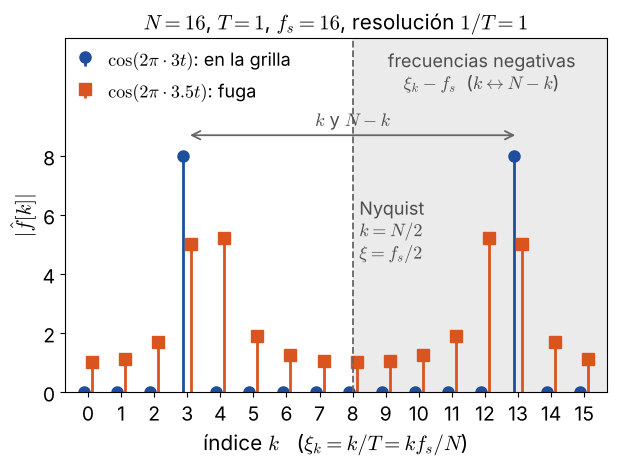

In [8]:
N, T = 16, 1.0
fs = N / T; dt = T / N
t = np.arange(N) * dt; k = np.arange(N); xi = k / T
f_a, f_b = 3.0, 3.5
Xa = np.fft.fft(np.cos(2 * np.pi * f_a * t)); Xb = np.fft.fft(np.cos(2 * np.pi * f_b * t))
print(f"N = {N}, T = {T}, f_s = {fs:g}, resolución 1/T = {1 / T:g}, Nyquist f_s/2 = {fs / 2:g}")
print(f"cos(2 pi {f_a:g} t): |hat f[k]| =", np.abs(Xa).round(6))
print(f"cos(2 pi {f_b:g} t): |hat f[k]| =", np.abs(Xb).round(3))
print(f"simetría hat f[N-k] = conj(hat f[k]) (señal real): {np.allclose(Xb[1:], np.conj(Xb[1:][::-1]))}")
X32 = np.fft.fft(np.cos(2 * np.pi * f_b * np.arange(2 * N) * dt))
print(f"con T = 2 (N = 32, misma f_s): cos(2 pi 3.5 t) cae en k = {np.argmax(np.abs(X32[:N]))} de la grilla xi_k = k/2 -> |hat f[k]| = {np.abs(X32).round(6)[[6, 7, 8]]} en k = 6, 7, 8")

with fuente(15):
    fig, ax = plt.subplots(figsize=(7, 4.6))
    for dx_, X_, col, mk, lab in [(-0.12, Xa, CICLO[0], "o", r"$\cos(2\pi\cdot 3t)$: en la grilla"), (0.12, Xb, CICLO[1], "s", r"$\cos(2\pi\cdot 3.5t)$: fuga")]:
        mline, sline, _ = ax.stem(k + dx_, np.abs(X_), markerfmt=mk, basefmt=" ", label=lab)
        plt.setp(sline, color=col, lw=2); plt.setp(mline, color=col, ms=8)
    ax.axvspan(N / 2, N, color="0.92", zorder=0)
    ax.axvline(N / 2, color="0.4", ls="--", lw=1.3); ax.text(N / 2 + 0.2, 6.6, "Nyquist\n$k = N/2$\n$\\xi = f_s/2$", fontsize=13, color="0.3", va="top")
    ax.text(11.9, 11.6, "frecuencias negativas\n$\\xi_k - f_s$  ($k \\leftrightarrow N - k$)", fontsize=13, color="0.3", ha="center", va="top")
    ax.annotate("", xy=(13, 8.7), xytext=(3, 8.7), arrowprops=dict(arrowstyle="<->", color="0.4", lw=1.3)); ax.text(8, 9.0, "$k$ y $N-k$", fontsize=13, color="0.3", ha="center")
    ax.set_xticks(k); ax.set_xlabel(r"índice $k$   ($\xi_k = k/T = k f_s/N$)"); ax.set_ylabel(r"$|\hat f[k]|$")
    ax.set_xlim(-0.7, N - 0.3); ax.set_ylim(0, 12); ax.set_yticks([0, 2, 4, 6, 8])
    ax.set_title(rf"$N = {N}$, $T = {T:g}$, $f_s = {fs:g}$, resolución $1/T = {1 / T:g}$")
    ax.legend(loc="upper left", fontsize=13, borderaxespad=0.2, handlelength=1.0)
    if GUARDAR: estilo.guardar(fig, "grilla-frecuencias")

## 14.7 Aliasing

**Figura `aliasing`**: tasa de muestreo $f_s = 16$ (muestras en $t_j = j/16$, $j = 0,\dots,15$). La señal $\cos(2\pi\cdot 13t)$ tiene frecuencia $13 > f_s/2 = 8$: en las muestras, $\cos(2\pi\cdot13\,j/16) = \cos(2\pi(16-3)j/16) = \cos(2\pi\cdot3\,j/16)$, así que produce **exactamente las mismas muestras** que $\cos(2\pi\cdot 3t)$: la frecuencia $13$ se pliega sobre $|13 - 16| = 3$. Lo comprobamos con las muestras y con la DFT: el pico aparece en $k = 3$, no en $13$ (que es el mismo índice, porque $\hat f[13] = \hat f[-3]$). Corrección respecto de la figura original: mismo contenido, con los parámetros en la figura y la fórmula del plegado.

f_s = 16, señal cos(2 pi 13 t): frecuencia 13 > Nyquist 8.0; alias |13 - 16| = 3
max |cos(2 pi 13 t_j) - cos(2 pi 3 t_j)| en las muestras: 7.7e-15
|DFT de las muestras| : [0. 0. 0. 8. 0. 0. 0. 0. 0. 0. 0. 0. 0. 8. 0. 0.]  -> pico en k = 3


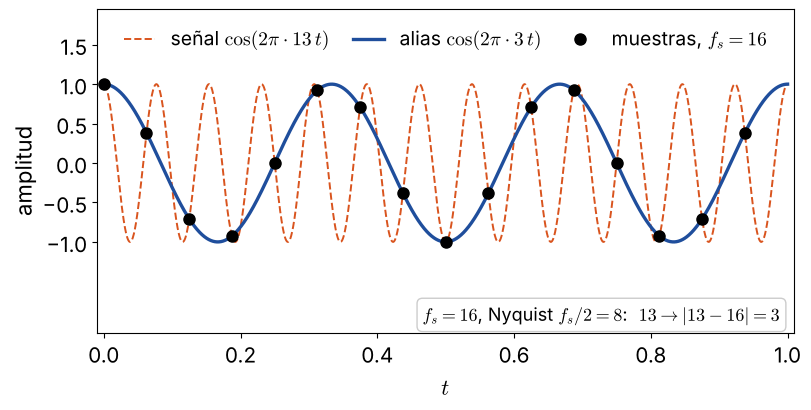

In [9]:
fs, f_alta = 16, 13
f_alias = abs(f_alta - fs)
tj = np.arange(fs) / fs                              # un segundo de muestras: N = 16, T = 1
tt = np.linspace(0, 1, 2001)
muestras = np.cos(2 * np.pi * f_alta * tj)
print(f"f_s = {fs}, señal cos(2 pi {f_alta} t): frecuencia {f_alta} > Nyquist {fs / 2}; alias |{f_alta} - {fs}| = {f_alias}")
print("max |cos(2 pi 13 t_j) - cos(2 pi 3 t_j)| en las muestras:", f"{np.abs(muestras - np.cos(2 * np.pi * f_alias * tj)).max():.1e}")
print("|DFT de las muestras| :", np.abs(np.fft.fft(muestras)).round(6), " -> pico en k =", np.argmax(np.abs(np.fft.fft(muestras))[:fs // 2 + 1]))

with fuente(16):
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.plot(tt, np.cos(2 * np.pi * f_alta * tt), color=COLORES["modelo"], lw=1.4, ls="--", label=rf"señal $\cos(2\pi\cdot{f_alta}\,t)$")
    ax.plot(tt, np.cos(2 * np.pi * f_alias * tt), color=COLORES["dato"], lw=2.4, label=rf"alias $\cos(2\pi\cdot{f_alias}\,t)$")
    ax.plot(tj, muestras, "o", color="black", ms=8, zorder=5, label=rf"muestras, $f_s = {fs}$")
    ax.set_xlabel("$t$"); ax.set_ylabel("amplitud"); ax.set_xlim(-0.01, 1.01); ax.set_ylim(-2.15, 1.95); ax.set_yticks([-1, -0.5, 0, 0.5, 1, 1.5])
    ax.legend(loc="upper center", ncol=3, columnspacing=1.2, handlelength=1.6)
    estilo.parametros(ax, rf"$f_s = {fs}$, Nyquist $f_s/2 = {fs // 2}$: $\ {f_alta} \to |{f_alta} - {fs}| = {f_alias}$", loc="lower right", fontsize=13)
    if GUARDAR: estilo.guardar(fig, "aliasing")

## Volvemos al problema: la señal de temperatura

Un año de mediciones horarias: $N = 8760$, $T = 1$ año, $f_s = 8760$ ciclos por año ($24$ por día), resolución $1$ ciclo por año, Nyquist $4380$ ciclos por año $= 12$ ciclos por día. El ciclo anual es $k = 1$, el diario $k = 365$ y el de 12 horas $k = 730$. Si en cambio midiéramos **una vez por día a las 15 h**, $f_s = 365$ ciclos por año y el ciclo diario ($365$ ciclos por año, con sus armónicos $730, 1095, \dots$) se pliega exactamente sobre $|365 - 365| = 0$: no se ve como oscilación sino como un corrimiento de la media. El texto dice que "la temperatura a las 15 h es más alta que la media diaria"; acá lo cuantificamos: la media de la serie de las 15 h menos la media horaria tiene que ser la suma de los armónicos del ciclo diario evaluados a las 15 h, $\sum_{m\ge1} A_{365m}\cos(2\pi m\tfrac{15}{24} + \phi_{365m})$, cuyo primer término es $A_{365}\cos(2\pi\tfrac{15}{24} + \phi_{365})$.

In [10]:
ruta = datos.obtener("temperatura_horaria.csv")
df = pd.read_csv(ruta, parse_dates=["fecha_hora"])
d23 = df[df.fecha_hora.dt.year == 2023].reset_index(drop=True)
T_h = d23.temp.values; N_h = len(T_h)                       # horaria: N = 8760, T = 1 año
X_h = np.fft.fft(T_h); A_h = 2 * np.abs(X_h) / N_h; phi_h = np.angle(X_h); A_h[0] /= 2
xi_h = np.arange(N_h) / 365                                  # ciclos por día (k ciclos por año / 365)
T_15 = d23.temp.values[d23.fecha_hora.dt.hour == 15]; N_15 = len(T_15)   # diaria a las 15 h: N = 365, T = 1 año
X_15 = np.fft.fft(T_15); A_15 = 2 * np.abs(X_15) / N_15; A_15[0] /= 2
xi_15 = np.arange(N_15) / 365

print(f"horaria: N = {N_h}, T = 1 año, f_s = {N_h} ciclos/año = {N_h / 365:g} por día, resolución 1 ciclo/año = {1 / 365:.5f} ciclos/día, Nyquist = {N_h / 2:g} ciclos/año = {N_h / 2 / 365:g} ciclos/día")
print(f"   A_1 = {A_h[1]:.2f} °C (anual), A_365 = {A_h[365]:.2f} °C (diario), A_730 = {A_h[730]:.2f} °C (12 h); media {A_h[0]:.2f} °C")
print(f"diaria a las 15 h: N = {N_15}, f_s = {N_15} ciclos/año, Nyquist = {N_15 / 2} ciclos/año = 0.5 ciclos/día;  A_1 = {A_15[1]:.2f} °C, media {A_15[0]:.2f} °C")
d_media = T_15.mean() - T_h.mean()
c1 = A_h[365] * np.cos(2 * np.pi * 15 / 24 + phi_h[365])
c_todos = sum(A_h[365 * m] * np.cos(2 * np.pi * m * 15 / 24 + phi_h[365 * m]) for m in range(1, 12)) + (X_h[4380].real / N_h) * np.cos(np.pi * 15)
print(f"\nmedia a las 15 h - media horaria = {d_media:+.3f} °C")
print(f"   primer armónico del ciclo diario a las 15 h: A_365 cos(2 pi 15/24 + phi_365) = {c1:+.3f} °C;  con todos los armónicos (k = 365 m): {c_todos:+.3f} °C")

horaria: N = 8760, T = 1 año, f_s = 8760 ciclos/año = 24 por día, resolución 1 ciclo/año = 0.00274 ciclos/día, Nyquist = 4380 ciclos/año = 12 ciclos/día
   A_1 = 6.92 °C (anual), A_365 = 2.76 °C (diario), A_730 = 0.83 °C (12 h); media 18.24 °C
diaria a las 15 h: N = 365, f_s = 365 ciclos/año, Nyquist = 182.5 ciclos/año = 0.5 ciclos/día;  A_1 = 6.92 °C, media 21.54 °C

media a las 15 h - media horaria = +3.300 °C
   primer armónico del ciclo diario a las 15 h: A_365 cos(2 pi 15/24 + phi_365) = +2.707 °C;  con todos los armónicos (k = 365 m): +3.300 °C


*Figura nueva `temperatura-muestreo`*: (a) el espectro de amplitudes $2|\hat f[k]|/N$ de la serie horaria de 2023 en ciclos por día ($\xi_k = k/365$), hasta Nyquist; (b) el de la serie diaria de las 15 h (Nyquist $0.5$ ciclos por día): el ciclo anual sigue ahí con la misma amplitud, el diario desapareció del espectro y reapareció en $k = 0$: la media de la serie de las 15 h es más alta que la media horaria en la cantidad que se imprime arriba (el primer armónico del ciclo diario da $A_{365}\cos(2\pi\tfrac{15}{24} + \phi_{365})\approx 2.7$ °C y el de 12 h agrega el resto).

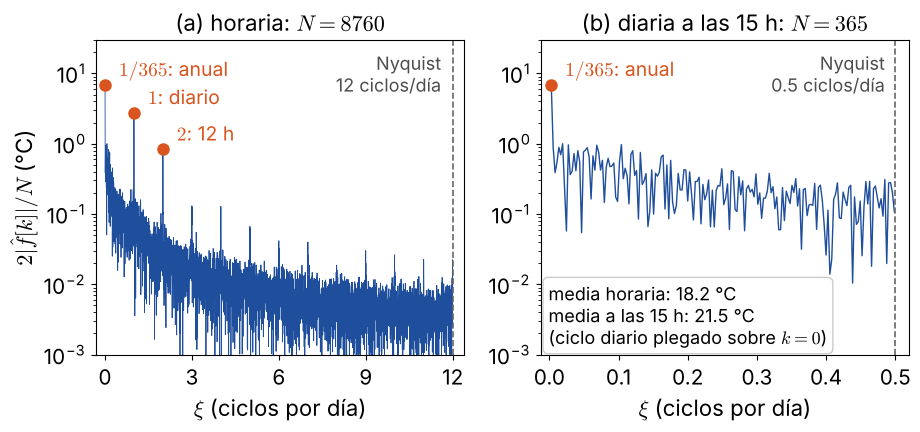

In [11]:
with fuente(16):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.6))
    m = (np.arange(N_h) >= 1) & (np.arange(N_h) <= N_h // 2)
    ax1.semilogy(xi_h[m], A_h[m], color=COLORES["dato"], lw=0.6)
    for kk, txt in [(1, "$1/365$: anual"), (365, "$1$: diario"), (730, "$2$: 12 h")]:
        ax1.plot(xi_h[kk], A_h[kk], "o", color=COLORES["modelo"], ms=8, zorder=5)
        ax1.annotate(txt, (xi_h[kk], A_h[kk]), (10, 6), textcoords="offset points", fontsize=14, color=COLORES["modelo"])
    ax1.axvline(12, color="0.4", ls="--", lw=1.2); ax1.text(11.6, 20, "Nyquist\n12 ciclos/día", ha="right", va="top", fontsize=13, color="0.3")
    ax1.set_xlabel(r"$\xi$ (ciclos por día)"); ax1.set_ylabel(r"$2|\hat f[k]|/N$ (°C)"); ax1.set_xlim(-0.3, 12.4); ax1.set_ylim(1e-3, 30); ax1.set_xticks([0, 3, 6, 9, 12])
    ax1.set_title("(a) horaria: $N = 8760$")
    m15 = (np.arange(N_15) >= 1) & (np.arange(N_15) <= N_15 // 2)
    ax2.semilogy(xi_15[m15], A_15[m15], color=COLORES["dato"], lw=1.0)
    ax2.plot(xi_15[1], A_15[1], "o", color=COLORES["modelo"], ms=8, zorder=5); ax2.annotate("$1/365$: anual", (xi_15[1], A_15[1]), (10, 6), textcoords="offset points", fontsize=14, color=COLORES["modelo"])
    ax2.axvline(0.5, color="0.4", ls="--", lw=1.2); ax2.text(0.485, 20, "Nyquist\n0.5 ciclos/día", ha="right", va="top", fontsize=13, color="0.3")
    ax2.set_xlabel(r"$\xi$ (ciclos por día)"); ax2.set_xlim(-0.012, 0.52); ax2.set_ylim(1e-3, 30); ax2.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax2.set_title("(b) diaria a las 15 h: $N = 365$")
    estilo.parametros(ax2, f"media horaria: {T_h.mean():.1f} °C\nmedia a las 15 h: {T_15.mean():.1f} °C\n(ciclo diario plegado sobre $k=0$)", loc="lower left", fontsize=13)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "temperatura-muestreo")

## 14.8 La transformada rápida de Fourier

Cooley–Tukey: si $N$ es par, separando las coordenadas pares $\mathbf f_p$ e impares $\mathbf f_i$,
$$\hat f[j] = \hat f_p[j] + \omega^j\hat f_i[j],\qquad \hat f[\tfrac N2 + j] = \hat f_p[j] - \omega^j\hat f_i[j],\qquad j = 0,\dots,\tfrac N2 - 1,$$
donde $\hat{\mathbf f}_p$ y $\hat{\mathbf f}_i$ son DFTs de tamaño $N/2$ y $\omega = e^{-2\pi i/N}$. Implementamos la recursión (para $N$ potencia de $2$), la comparamos con `np.fft.fft` y reproducimos el caso $N = 4$ del texto: $\hat f[0] = \hat f_p[0] + \hat f_i[0]$, $\hat f[1] = \hat f_p[1] - i\hat f_i[1]$, $\hat f[2] = \hat f_p[0] - \hat f_i[0]$, $\hat f[3] = \hat f_p[1] + i\hat f_i[1]$. Contamos también las multiplicaciones complejas: $\frac N2\log_2 N$ en la FFT contra $N^2$ en el producto por $A(\omega)$.

In [12]:
def fft_recursiva(f):
    '''DFT por el algoritmo de Cooley-Tukey (N potencia de 2): hat f[j] = hat f_p[j] + w^j hat f_i[j], hat f[N/2 + j] = hat f_p[j] - w^j hat f_i[j].'''
    f = np.asarray(f, dtype=complex); N = len(f)
    if N == 1:
        return f
    Fp, Fi = fft_recursiva(f[0::2]), fft_recursiva(f[1::2])
    w = np.exp(-2j * np.pi * np.arange(N // 2) / N)          # w^j, j = 0..N/2-1  (los "twiddles")
    return np.concatenate([Fp + w * Fi, Fp - w * Fi])

f4 = np.array([1.0, 2.0, 0.0, -1.0])
Fp, Fi = np.fft.fft(f4[0::2]), np.fft.fft(f4[1::2])
print("N = 4, f =", f4, ": hat f_p =", Fp, ", hat f_i =", Fi)
print("   hat f = [Fp0 + Fi0, Fp1 - i Fi1, Fp0 - Fi0, Fp1 + i Fi1] =", np.array([Fp[0] + Fi[0], Fp[1] - 1j * Fi[1], Fp[0] - Fi[0], Fp[1] + 1j * Fi[1]]))
print("   np.fft.fft(f)                                    =", np.fft.fft(f4), "\n   A(omega) f                                       =", (matriz_fourier(4) @ f4).round(12))
for N in [8, 256, 4096]:
    f = np.random.default_rng(1).normal(size=N)
    print(f"N = {N:5d}: max |fft_recursiva - np.fft.fft| = {np.abs(fft_recursiva(f) - np.fft.fft(f)).max():.1e};  multiplicaciones complejas: FFT (N/2) log2 N = {N // 2 * int(np.log2(N)):8d},  matriz N^2 = {N**2:9d}")

N = 4, f = [ 1.  2.  0. -1.] : hat f_p = [1.+0.j 1.+0.j] , hat f_i = [1.+0.j 3.+0.j]
   hat f = [Fp0 + Fi0, Fp1 - i Fi1, Fp0 - Fi0, Fp1 + i Fi1] = [2.+0.j 1.-3.j 0.+0.j 1.+3.j]
   np.fft.fft(f)                                    = [2.+0.j 1.-3.j 0.+0.j 1.+3.j] 
   A(omega) f                                       = [2.+0.j 1.-3.j 0.+0.j 1.+3.j]
N =     8: max |fft_recursiva - np.fft.fft| = 4.4e-16;  multiplicaciones complejas: FFT (N/2) log2 N =       12,  matriz N^2 =        64
N =   256: max |fft_recursiva - np.fft.fft| = 1.8e-14;  multiplicaciones complejas: FFT (N/2) log2 N =     1024,  matriz N^2 =     65536
N =  4096: max |fft_recursiva - np.fft.fft| = 1.6e-13;  multiplicaciones complejas: FFT (N/2) log2 N =    24576,  matriz N^2 =  16777216


*Figura nueva `fft-mariposa`*: una etapa del algoritmo para $N = 8$. A la izquierda el vector $\mathbf f$; se lo reordena en pares e impares, cada mitad pasa por una DFT de tamaño $4$ (que a su vez se calcula igual, con dos DFTs de tamaño 2), y las salidas se combinan de a pares con los factores $\omega^j$ ($\omega = e^{-2\pi i/8}$): cada "mariposa" produce $\hat f[j]$ (suma) y $\hat f[j+4]$ (resta).

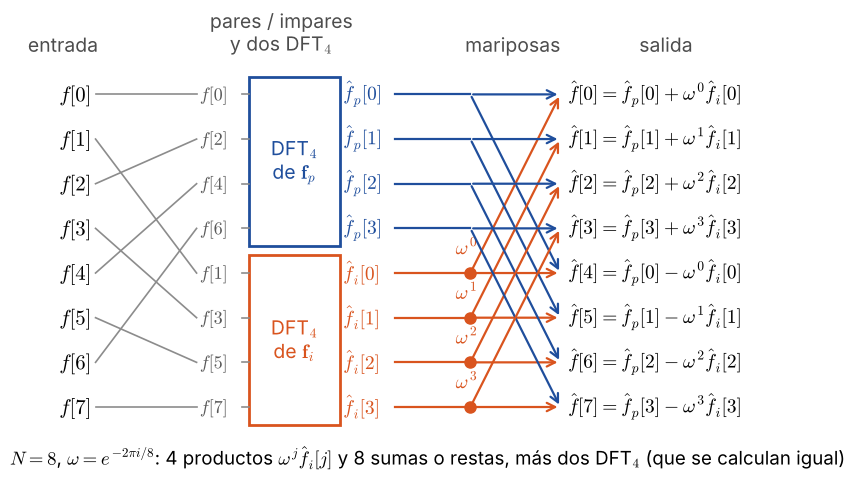

In [13]:
with plt.rc_context({"font.size": 15, "mathtext.fontset": "cm"}):
    fig, ax = plt.subplots(figsize=(9, 5.8))
    ax.set_xlim(-0.2, 10.5); ax.set_ylim(-1.5, 8.5); ax.axis("off")
    orden = [0, 2, 4, 6, 1, 3, 5, 7]            # reordenamiento: pares arriba, impares abajo
    yin = lambda j: 7 - j                       # altura de f[j] en la entrada
    ymid = lambda pos: 7 - pos                  # altura en la columna reordenada
    x0, x1, xb0, xb1, x3, x4 = 0.0, 1.55, 2.35, 3.75, 5.75, 7.25   # entrada, reordenado, caja DFT_4, twiddle, salida
    for j in range(8):
        ax.text(x0 - 0.05, yin(j), f"$f[{j}]$", ha="right", va="center", fontsize=15)
        pos = orden.index(j)
        ax.plot([x0, x1], [yin(j), ymid(pos)], color="0.55", lw=1.2)
        ax.text(x1 + 0.05, ymid(pos), f"$f[{j}]$", ha="left", va="center", fontsize=13, color="0.35")
        ax.plot([x1 + 0.7, xb0], [ymid(pos), ymid(pos)], color="0.55", lw=1.2)
    for (lo, hi, nombre, col) in [(0, 3, "DFT$_4$\nde $\\mathbf{f}_p$", CICLO[0]), (4, 7, "DFT$_4$\nde $\\mathbf{f}_i$", CICLO[1])]:
        ax.add_patch(plt.Rectangle((xb0, ymid(hi) - 0.4), xb1 - xb0, hi - lo + 0.8, fc="white", ec=col, lw=2))
        ax.text((xb0 + xb1) / 2, (ymid(lo) + ymid(hi)) / 2, nombre, ha="center", va="center", fontsize=14, color=col)
    for j in range(4):
        yp, yi = ymid(j), ymid(j + 4)
        ax.text(xb1 + 0.05, yp, rf"$\hat f_p[{j}]$", ha="left", va="center", fontsize=14, color=CICLO[0])
        ax.text(xb1 + 0.05, yi, rf"$\hat f_i[{j}]$", ha="left", va="center", fontsize=14, color=CICLO[1])
        ax.plot([xb1 + 0.85, x3], [yp, yp], color=CICLO[0], lw=1.6)
        ax.plot([xb1 + 0.85, x3], [yi, yi], color=CICLO[1], lw=1.6)
        ax.plot(x3, yi, "o", color=CICLO[1], ms=8); ax.text(x3 - 0.05, yi + 0.3, rf"$\omega^{j}$", ha="center", va="bottom", fontsize=14, color=CICLO[1])
        # mariposa: la rama par va a f[j] (+) y a f[j+4] (+); la impar (multiplicada por w^j) va a f[j] (+) y a f[j+4] (-)
        for (ya, yb, col) in [(yp, yp, CICLO[0]), (yp, yi, CICLO[0]), (yi, yp, CICLO[1]), (yi, yi, CICLO[1])]:
            ax.annotate("", xy=(x4 - 0.12, yb), xytext=(x3, ya), arrowprops=dict(arrowstyle="->", color=col, lw=1.6))
        ax.text(x4, yp, rf"$\hat f[{j}] = \hat f_p[{j}] + \omega^{j}\hat f_i[{j}]$", ha="left", va="center", fontsize=14)
        ax.text(x4, yi, rf"$\hat f[{j + 4}] = \hat f_p[{j}] - \omega^{j}\hat f_i[{j}]$", ha="left", va="center", fontsize=14)
    for x, txt in [(x0 - 0.5, "entrada"), ((x1 + xb1) / 2 + 0.2, "pares / impares\ny dos DFT$_4$"), ((x3 + x4) / 2 - 0.1, "mariposas"), (x4 + 1.5, "salida")]:
        ax.text(x, 7.85, txt, ha="center", va="bottom", fontsize=14, color="0.3")
    ax.text(5.1, -1.3, r"$N = 8$, $\omega = e^{-2\pi i/8}$: 4 productos $\omega^j\hat f_i[j]$ y 8 sumas o restas, más dos DFT$_4$ (que se calculan igual)", ha="center", fontsize=13.5)
    if GUARDAR: estilo.guardar(fig, "fft-mariposa")

*Figura nueva `fft-costo`*: tiempo de cómputo de la DFT por producto con la matriz $A(\omega)$ (ya construida; el costo de construirla es también $N^2$) contra `np.fft.fft`, en función de $N$, en escala log-log, con las rectas $N^2$ y $N\log_2 N$ como referencia. Con $N = 8760$ (un año de temperatura horaria) o $N \sim 10^6$ (un minuto de audio) la diferencia es de varios órdenes de magnitud.

N =    16: matriz     0.001 ms,  np.fft.fft      3.9 us,  cociente     0.3
N =    32: matriz     0.001 ms,  np.fft.fft      4.1 us,  cociente     0.4
N =    64: matriz     0.004 ms,  np.fft.fft      4.4 us,  cociente     0.8
N =   128: matriz     0.005 ms,  np.fft.fft      5.1 us,  cociente     1.0
N =   256: matriz     0.011 ms,  np.fft.fft      6.2 us,  cociente     1.8
N =   512: matriz    18.434 ms,  np.fft.fft      8.5 us,  cociente  2165.9
N =  1024: matriz    19.325 ms,  np.fft.fft     12.9 us,  cociente  1497.1
N =  2048: matriz    15.986 ms,  np.fft.fft     21.2 us,  cociente   753.9
N =  4096: matriz    58.571 ms,  np.fft.fft     39.4 us,  cociente  1487.4
N = 4194304: np.fft.fft 753.2 ms (la matriz tendría 281 TB)


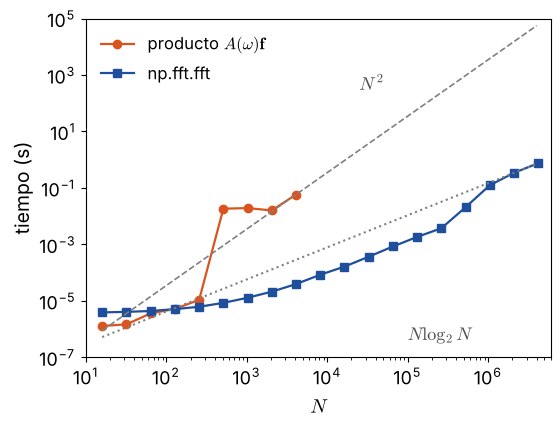

In [14]:
def tiempo(func, repeticiones=15):
    '''Mejor tiempo (s) de func() en varias repeticiones.'''
    ts = []
    for _ in range(repeticiones):
        t0 = time.perf_counter(); func(); ts.append(time.perf_counter() - t0)
    return min(ts)

Ns_mat = 2 ** np.arange(4, 13); Ns_fft = 2 ** np.arange(4, 23)
t_mat, t_fft = [], []
for N in Ns_mat:
    f = np.random.default_rng(2).normal(size=N); A = matriz_fourier(N)
    t_mat.append(tiempo(lambda: A @ f))
for N in Ns_fft:
    f = np.random.default_rng(2).normal(size=N)
    t_fft.append(tiempo(lambda: np.fft.fft(f)))
t_mat, t_fft = np.array(t_mat), np.array(t_fft)
for N, tm, tf in zip(Ns_mat, t_mat, t_fft[:len(Ns_mat)]):
    print(f"N = {N:5d}: matriz {1e3 * tm:9.3f} ms,  np.fft.fft {1e6 * tf:8.1f} us,  cociente {tm / tf:7.1f}")
print(f"N = {Ns_fft[-1]}: np.fft.fft {1e3 * t_fft[-1]:.1f} ms (la matriz tendría {Ns_fft[-1]**2 * 16 / 1e12:.0f} TB)")

fig, ax = plt.subplots(figsize=(6, 4.4))
ax.loglog(Ns_mat, t_mat, "o-", color=CICLO[1], label=r"producto $A(\omega)\mathbf{f}$")
ax.loglog(Ns_fft, t_fft, "s-", color=CICLO[0], label="np.fft.fft")
NN = np.array([16, 4e6])
ax.loglog(NN, t_mat[-1] * (NN / Ns_mat[-1]) ** 2, "--", color="0.5", lw=1.2); ax.text(2.5e4, 3e2, "$N^2$", fontsize=13, color="0.3")
ax.loglog(NN, t_fft[-1] * (NN * np.log2(NN)) / (Ns_fft[-1] * np.log2(Ns_fft[-1])), ":", color="0.5", lw=1.5); ax.text(1e5, 4e-7, r"$N\log_2 N$", fontsize=13, color="0.3")
ax.set_xlabel("$N$"); ax.set_ylabel("tiempo (s)"); ax.set_xlim(10, 6e6); ax.set_ylim(1e-7, 1e5)
ax.legend(loc="upper left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "fft-costo")

## Para experimentar

1. Calculá numéricamente la transformada del triángulo $\max(0, 1-|x|)$ y de la "campana" $1/(1+x^2)$, graficá $|\hat f(\xi)|$ en escala log-log y medí cómo decae: $1/\xi^2$ para el triángulo (continuo con quiebres), exponencial para la campana (analítica). Compará con el $1/\xi$ de la indicadora: es la misma relación regularidad–decaimiento de los coeficientes de la serie de Fourier.
2. Con la temperatura: muestreá el año 2023 una vez por día a las 3 h, a las 9 h y a las 21 h y calculá en cada caso la media y el espectro. ¿Cómo depende el corrimiento de la media de la hora elegida? Verificá que sigue la curva $A_{365}\cos(2\pi h/24 + \phi_{365})$ más el armónico de 12 h. ¿Y si muestreás cada 36 horas?
3. Tomá $\cos(2\pi\cdot 3.5t)$ con $N = 16$ y multiplicalo por una ventana de Hann, $w_j = \frac12(1 - \cos(2\pi j/N))$, antes de la DFT: ¿qué pasa con la fuga espectral? ¿Y con la altura del pico? Repetí con $N = 64$.
4. Extendé `fft_recursiva` a $N$ divisible por $3$ (separando los índices módulo 3, con tres DFTs de tamaño $N/3$ y los factores $\omega^j$, $\omega^{2j}$) y verificá contra `np.fft.fft` para $N = 3\cdot 2^m$. ¿Cuántas multiplicaciones complejas cuesta?